In [1]:
import sys
sys.path.insert(0, ".")  # so `from src.helpers import ...` resolves when run as a script

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import roc_curve, precision_recall_curve, confusion_matrix

In [4]:
from src.helpers import (
    load_and_clean_data, custom_smote, evaluate_model,
    find_optimal_threshold, business_cost
)

In [5]:
sns.set_style("whitegrid")
RANDOM_STATE = 42

In [6]:
DATA_PATH = "/mnt/user-data/uploads/diabetes.csv"  # adjust if you move the file

In [7]:
# Business framing (health-screening campaign analogy):
#  - Cost of a False Positive: an unnecessary follow-up diagnostic test -> $20
#  - Cost of a False Negative: a missed/undiagnosed diabetic patient    -> $200
COST_FP = 20
COST_FN = 200

In [8]:
# Checks for the classic "zero as missing value" issue in Glucose,
# BloodPressure, SkinThickness, Insulin, BMI, and imputes with the
# within-class median if any zero-placeholders are found.
df, clean_report = load_and_clean_data(DATA_PATH)
print("Cleaning report:", clean_report)
print("Final shape:", df.shape)
print(df.head(), "\n")

Cleaning report: {'duplicates_removed': 0, 'zero_placeholders_found': {'Glucose': 0, 'BloodPressure': 0, 'SkinThickness': 0, 'Insulin': 0, 'BMI': 0}, 'missing_after_clean': {'Glucose': 0, 'BloodPressure': 0, 'SkinThickness': 0, 'Insulin': 0, 'BMI': 0}}
Final shape: (768, 9)
   Pregnancies  Glucose  BloodPressure  ...  DiabetesPedigreeFunction  Age  Outcome
0            6      148           72.0  ...                     0.627   50        1
1            1       85           66.0  ...                     0.351   31        0
2            8      183           64.0  ...                     0.672   32        1
3            1       89           66.0  ...                     0.167   21        0
4            0      137           40.0  ...                     2.288   33        1

[5 rows x 9 columns] 



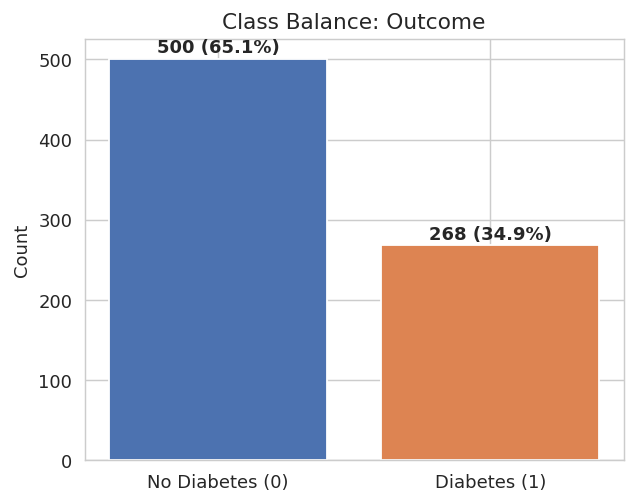

In [9]:
# Class balance
fig, ax = plt.subplots(figsize=(5, 4))
counts = df["Outcome"].value_counts().sort_index()
ax.bar(["No Diabetes (0)", "Diabetes (1)"], counts.values, color=["#4C72B0", "#DD8452"])
for i, v in enumerate(counts.values):
    ax.text(i, v + 8, f"{v} ({v/len(df):.1%})", ha="center", fontweight="bold")
ax.set_title("Class Balance: Outcome")
ax.set_ylabel("Count")
plt.tight_layout()
plt.savefig("outputs/01_class_balance.png", dpi=130)
plt.show()

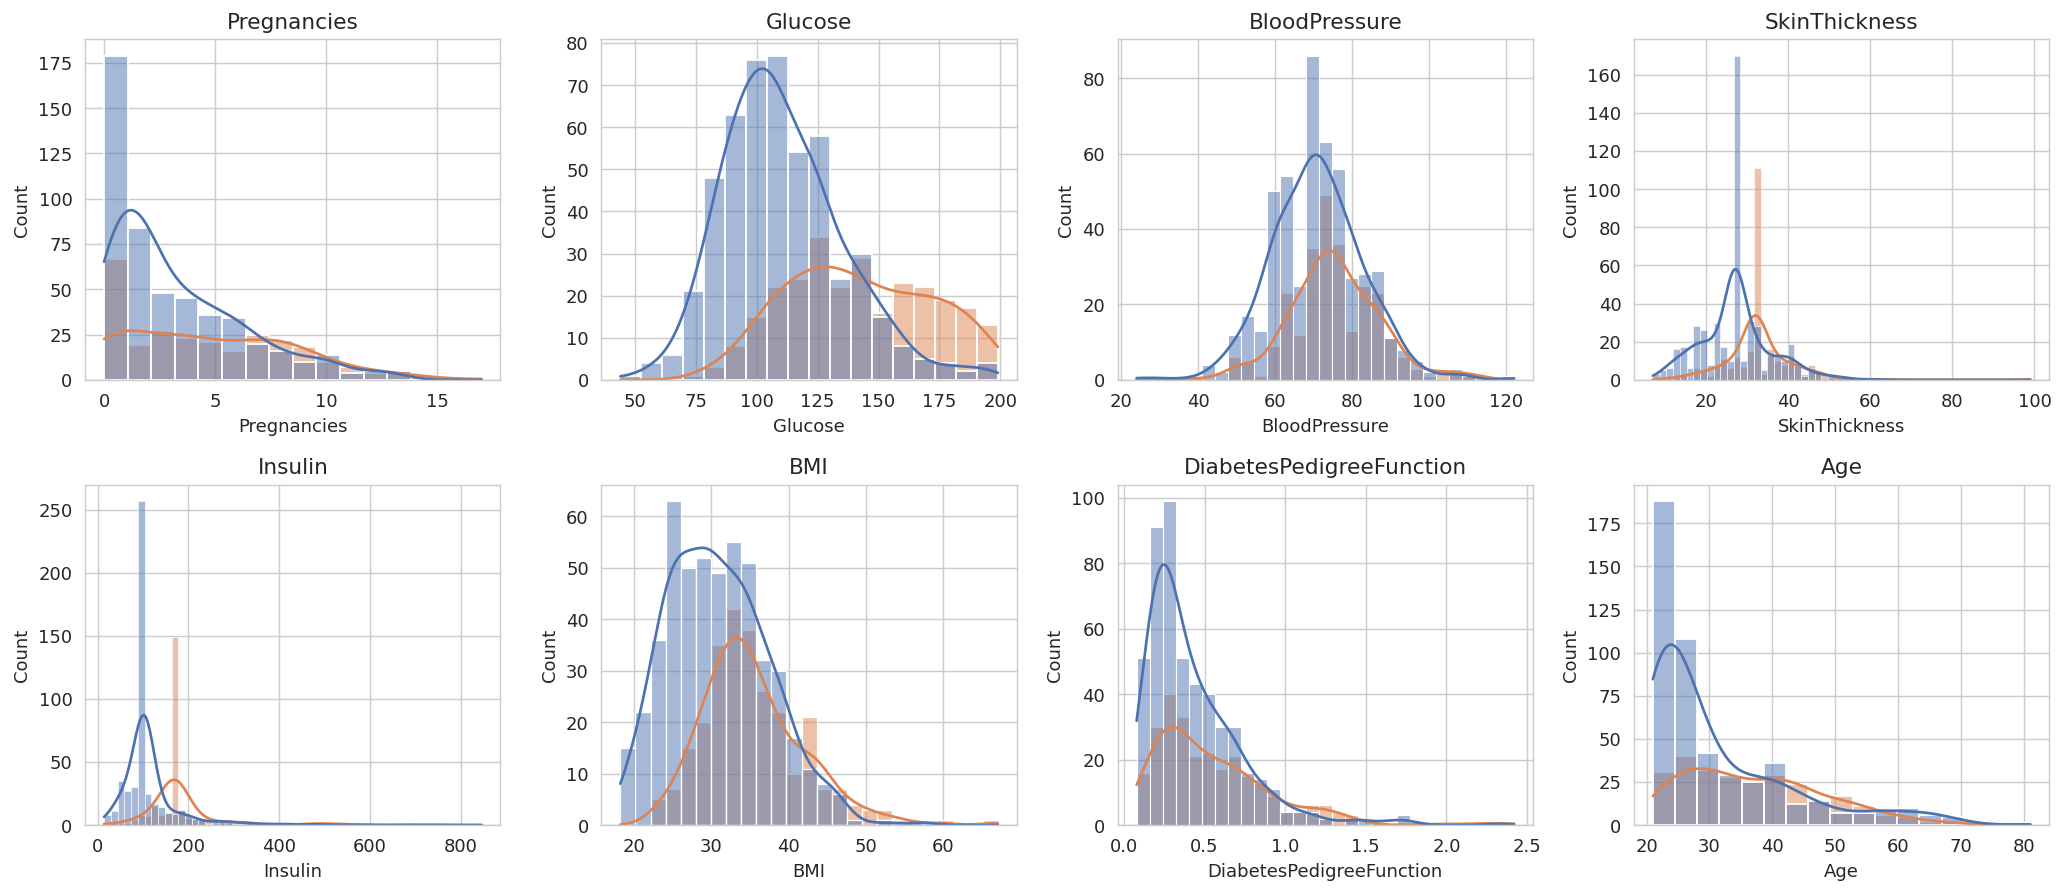

In [10]:
# Feature distributions by class
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
num_cols = [c for c in df.columns if c != "Outcome"]
for ax, col in zip(axes.ravel(), num_cols):
    sns.histplot(data=df, x=col, hue="Outcome", kde=True, ax=ax,
                 palette=["#4C72B0", "#DD8452"], alpha=0.5, legend=False)
    ax.set_title(col)
plt.tight_layout()
plt.savefig("outputs/02_feature_distributions.png", dpi=130)
plt.show()

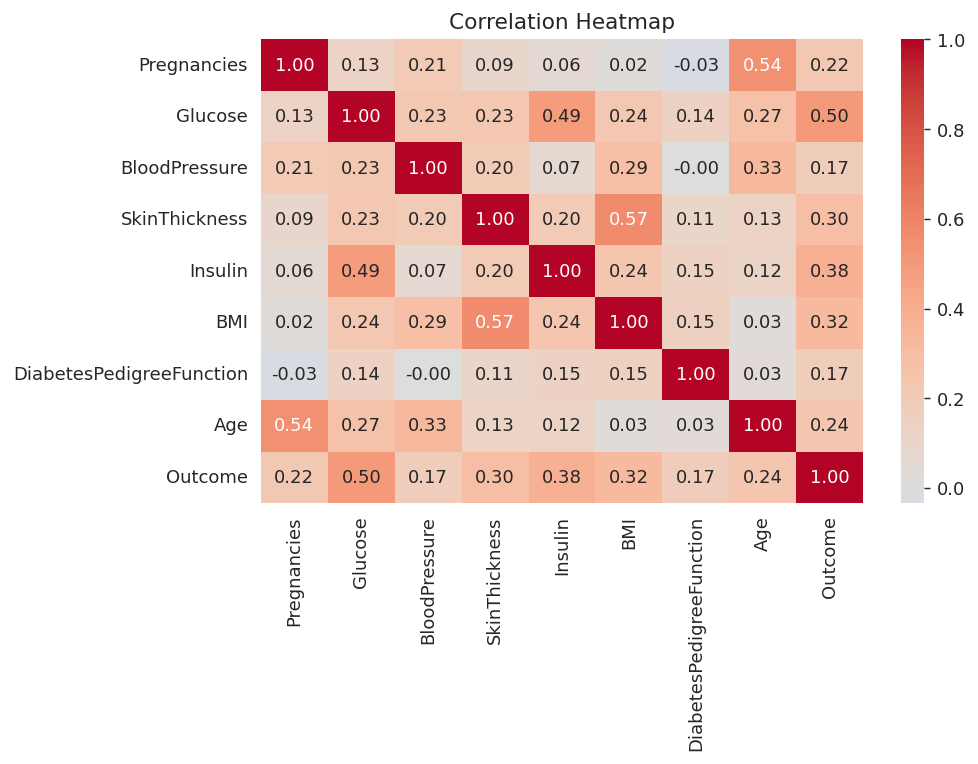

In [11]:
# Correlation heatmap
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlation Heatmap")
plt.tight_layout()
plt.savefig("outputs/03_correlation_heatmap.png", dpi=130)
plt.show()

In [12]:
X = df.drop(columns=["Outcome"])
y = df["Outcome"]

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
print("Train shape:", X_train.shape, "| Test shape:", X_test.shape)
print(f"Train positive rate: {y_train.mean():.3f} | Test positive rate: {y_test.mean():.3f}")

Train shape: (614, 8) | Test shape: (154, 8)
Train positive rate: 0.349 | Test positive rate: 0.351


In [14]:
# Scaler is fit ONLY on the training data - the test set is only ever
# transformed, never used to fit anything (no data leakage).
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

In [15]:
X_train_sm, y_train_sm = custom_smote(X_train_s, y_train.values, k=5, random_state=RANDOM_STATE)
print("Training set before SMOTE:", X_train_s.shape, "class counts:", np.bincount(y_train.values))
print("Training set after  SMOTE:", X_train_sm.shape, "class counts:", np.bincount(y_train_sm))

Training set before SMOTE: (614, 8) class counts: [400 214]
Training set after  SMOTE: (800, 8) class counts: [400 400]


In [16]:
baselines = {
    "Majority-class baseline": DummyClassifier(strategy="most_frequent", random_state=RANDOM_STATE),
    "Stratified-random baseline": DummyClassifier(strategy="stratified", random_state=RANDOM_STATE),
}
baseline_rows = []
for name, model in baselines.items():
    model.fit(X_train_s, y_train)
    proba = model.predict_proba(X_test_s)[:, 1]
    metrics = evaluate_model(y_test.values, proba)
    baseline_rows.append({"model": name, "strategy": "n/a", **metrics})

In [17]:
baseline_df = pd.DataFrame(baseline_rows)
print(baseline_df.to_string(index=False))

                     model strategy  threshold  accuracy  precision  recall       f1  roc_auc   pr_auc
   Majority-class baseline      n/a        0.5  0.649351   0.000000 0.00000 0.000000 0.500000 0.350649
Stratified-random baseline      n/a        0.5  0.597403   0.416667 0.37037 0.392157 0.545185 0.375100


In [18]:
# 5 classifiers x up to 3 imbalance strategies = 14 model/strategy combos,
# all scored on the same held-out test set.
model_factories = {
    "Logistic Regression": lambda **kw: LogisticRegression(max_iter=2000, random_state=RANDOM_STATE, **kw),
    "Decision Tree": lambda **kw: DecisionTreeClassifier(max_depth=6, random_state=RANDOM_STATE, **kw),
    "Random Forest": lambda **kw: RandomForestClassifier(n_estimators=300, max_depth=8, random_state=RANDOM_STATE, **kw),
    "SVM (RBF kernel)": lambda **kw: SVC(probability=True, random_state=RANDOM_STATE, **kw),
    "KNN": lambda **kw: KNeighborsClassifier(n_neighbors=9),  # no class_weight support
}

In [19]:
strategies = {
    "raw (imbalanced)": (X_train_s, y_train.values, {}),
    "SMOTE-resampled": (X_train_sm, y_train_sm, {}),
    "class_weight='balanced'": (X_train_s, y_train.values, {"class_weight": "balanced"}),
}

In [20]:
results = []
fitted_models = {}  # keep every fitted model so we can plot ROC/PR later
for model_name, factory in model_factories.items():
    for strat_name, (Xtr, ytr, kwargs) in strategies.items():
        if strat_name == "class_weight='balanced'" and model_name == "KNN":
            continue  # KNN has no class_weight parameter
        model = factory(**kwargs)
        model.fit(Xtr, ytr)
        proba = model.predict_proba(X_test_s)[:, 1]
        metrics = evaluate_model(y_test.values, proba)
        results.append({"model": model_name, "strategy": strat_name, **metrics})
        fitted_models[(model_name, strat_name)] = (model, proba)

In [21]:
results_df = pd.DataFrame(results).sort_values("f1", ascending=False).reset_index(drop=True)
print(results_df.to_string(index=False))
results_df.to_csv("outputs/model_comparison_results.csv", index=False)

              model                strategy  threshold  accuracy  precision   recall       f1  roc_auc   pr_auc
      Decision Tree class_weight='balanced'        0.5  0.876623   0.786885 0.888889 0.834783 0.904352 0.808208
      Decision Tree         SMOTE-resampled        0.5  0.870130   0.793103 0.851852 0.821429 0.886389 0.743337
      Random Forest         SMOTE-resampled        0.5  0.863636   0.779661 0.851852 0.814159 0.941852 0.906448
      Random Forest        raw (imbalanced)        0.5  0.863636   0.811321 0.796296 0.803738 0.947778 0.924205
      Random Forest class_weight='balanced'        0.5  0.863636   0.811321 0.796296 0.803738 0.947037 0.915226
      Decision Tree        raw (imbalanced)        0.5  0.857143   0.785714 0.814815 0.800000 0.864630 0.766452
   SVM (RBF kernel)         SMOTE-resampled        0.5  0.837662   0.745763 0.814815 0.778761 0.902500 0.803481
   SVM (RBF kernel) class_weight='balanced'        0.5  0.824675   0.745455 0.759259 0.752294 0.898148 0

In [22]:
best_per_model = (
    results_df.loc[results_df.groupby("model")["f1"].idxmax()]
    .sort_values("f1", ascending=False)
)
print(best_per_model.to_string(index=False))
best_per_model.to_csv("outputs/best_strategy_per_model.csv", index=False)

              model                strategy  threshold  accuracy  precision   recall       f1  roc_auc   pr_auc
      Decision Tree class_weight='balanced'        0.5  0.876623   0.786885 0.888889 0.834783 0.904352 0.808208
      Random Forest         SMOTE-resampled        0.5  0.863636   0.779661 0.851852 0.814159 0.941852 0.906448
   SVM (RBF kernel)         SMOTE-resampled        0.5  0.837662   0.745763 0.814815 0.778761 0.902500 0.803481
                KNN         SMOTE-resampled        0.5  0.772727   0.623377 0.888889 0.732824 0.868148 0.753747
Logistic Regression         SMOTE-resampled        0.5  0.759740   0.619718 0.814815 0.704000 0.828519 0.644755


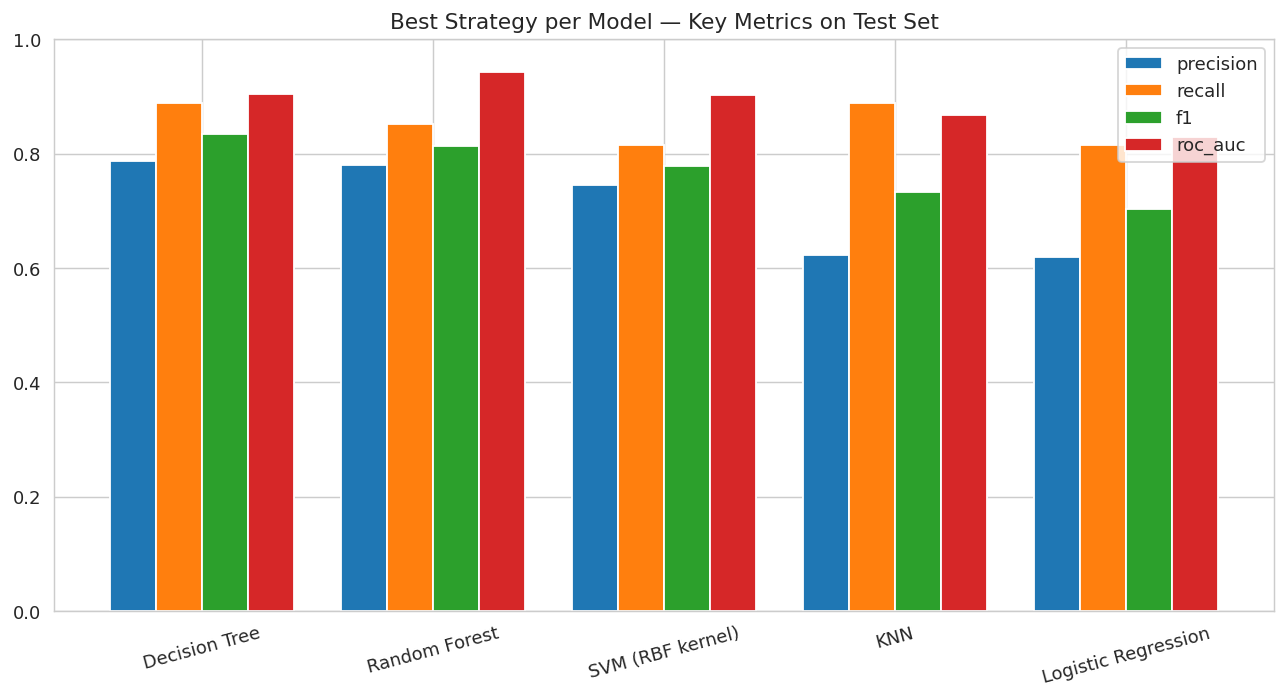

In [23]:
# Bar chart: best strategy per model across key metrics
metrics_to_plot = ["precision", "recall", "f1", "roc_auc"]
fig, ax = plt.subplots(figsize=(10, 5.5))
x = np.arange(len(best_per_model))
width = 0.2
for i, m in enumerate(metrics_to_plot):
    ax.bar(x + i * width, best_per_model[m], width, label=m)
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(best_per_model["model"], rotation=15)
ax.set_ylim(0, 1)
ax.set_title("Best Strategy per Model — Key Metrics on Test Set")
ax.legend()
plt.tight_layout()
plt.savefig("outputs/04_model_comparison_bars.png", dpi=130)
plt.show()

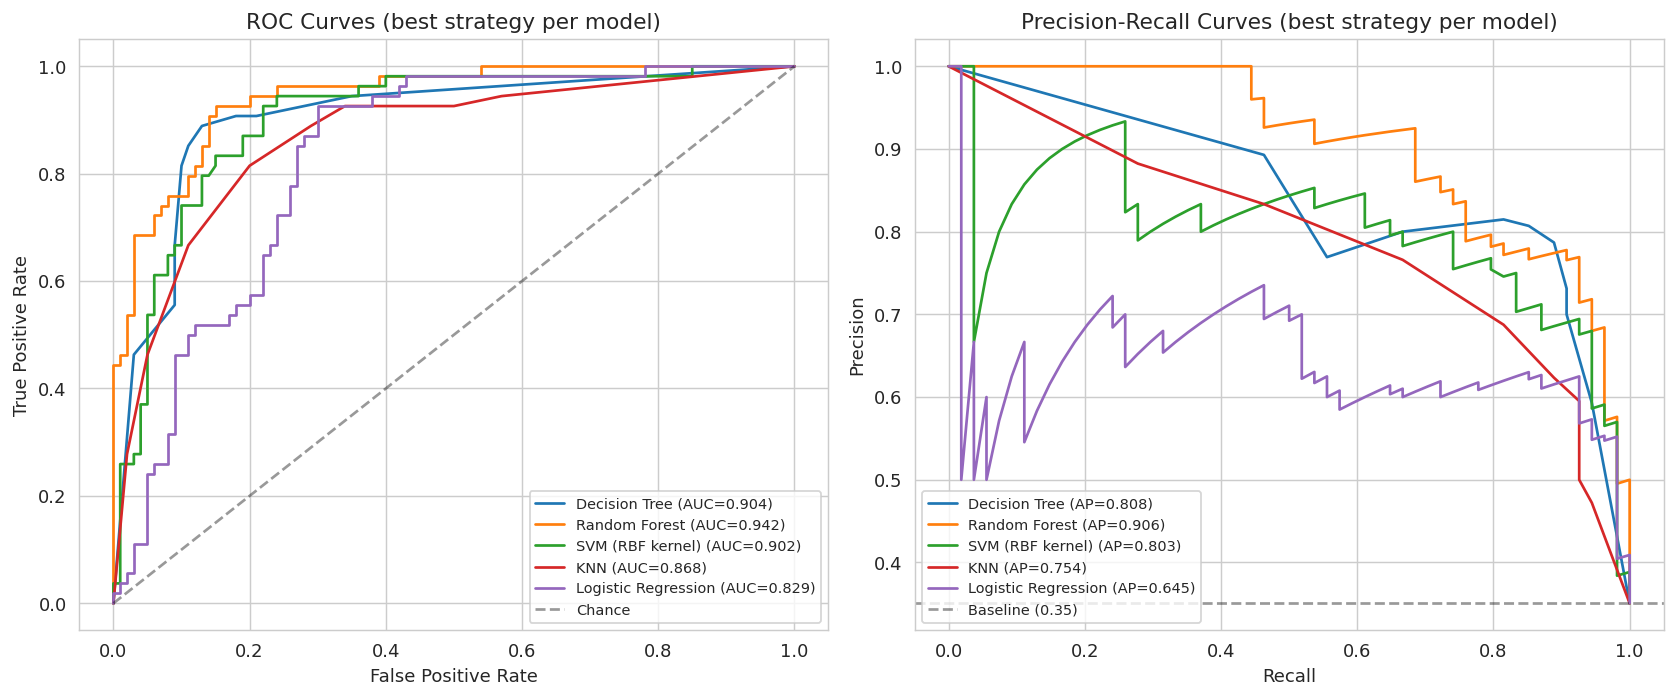

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
for _, row in best_per_model.iterrows():
    model, proba = fitted_models[(row["model"], row["strategy"])]
    fpr, tpr, _ = roc_curve(y_test, proba)
    axes[0].plot(fpr, tpr, label=f"{row['model']} (AUC={row['roc_auc']:.3f})")

    prec, rec, _ = precision_recall_curve(y_test, proba)
    axes[1].plot(rec, prec, label=f"{row['model']} (AP={row['pr_auc']:.3f})")

axes[0].plot([0, 1], [0, 1], "k--", alpha=0.4, label="Chance")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curves (best strategy per model)")
axes[0].legend(fontsize=8)

pos_rate = y_test.mean()
axes[1].axhline(pos_rate, color="k", linestyle="--", alpha=0.4, label=f"Baseline ({pos_rate:.2f})")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curves (best strategy per model)")
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.savefig("outputs/05_roc_pr_curves.png", dpi=130)
plt.show()

In [25]:
# Model chosen by RANKING quality (ROC-AUC), not F1 at the default 0.5
# threshold, since we are about to move the threshold away from 0.5 anyway.
best_overall = best_per_model.sort_values("roc_auc", ascending=False).iloc[0]
best_model, best_proba = fitted_models[(best_overall["model"], best_overall["strategy"])]
print(f"Model selected for deployment: {best_overall['model']} | strategy: {best_overall['strategy']}")
print(f"  ROC-AUC: {best_overall['roc_auc']:.3f} | PR-AUC: {best_overall['pr_auc']:.3f}")

Model selected for deployment: Random Forest | strategy: SMOTE-resampled
  ROC-AUC: 0.942 | PR-AUC: 0.906


In [26]:
best_threshold, cost_df = find_optimal_threshold(y_test.values, best_proba, COST_FP, COST_FN)
cost_at_default, counts_default = business_cost(y_test.values, best_proba, 0.5, COST_FP, COST_FN)
cost_at_best, counts_best = business_cost(y_test.values, best_proba, best_threshold, COST_FP, COST_FN)

In [27]:
print(f"\nDefault threshold 0.50 -> total cost=${cost_at_default:.0f} | confusion counts={counts_default}")
print(f"Optimal threshold {best_threshold:.2f} -> total cost=${cost_at_best:.0f} | confusion counts={counts_best}")
print(f"\nEstimated savings from threshold tuning: ${cost_at_default - cost_at_best:.0f} "
      f"({(cost_at_default - cost_at_best) / cost_at_default:.1%} reduction)")


Default threshold 0.50 -> total cost=$1860 | confusion counts={'tn': np.int64(87), 'fp': np.int64(13), 'fn': np.int64(8), 'tp': np.int64(46)}
Optimal threshold 0.21 -> total cost=$900 | confusion counts={'tn': np.int64(75), 'fp': np.int64(25), 'fn': np.int64(2), 'tp': np.int64(52)}

Estimated savings from threshold tuning: $960 (51.6% reduction)


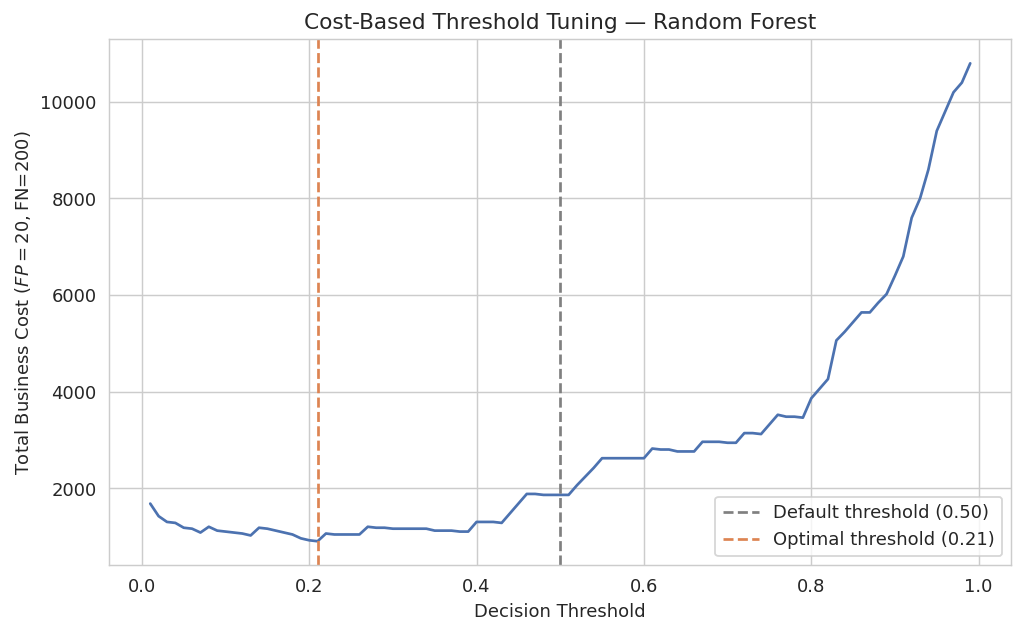

In [28]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(cost_df["threshold"], cost_df["cost"], color="#4C72B0")
ax.axvline(0.5, color="gray", linestyle="--", label="Default threshold (0.50)")
ax.axvline(best_threshold, color="#DD8452", linestyle="--", label=f"Optimal threshold ({best_threshold:.2f})")
ax.set_xlabel("Decision Threshold")
ax.set_ylabel(f"Total Business Cost ($FP={COST_FP}, $FN={COST_FN})")
ax.set_title(f"Cost-Based Threshold Tuning — {best_overall['model']}")
ax.legend()
plt.tight_layout()
plt.savefig("outputs/06_threshold_cost_curve.png", dpi=130)
plt.show()

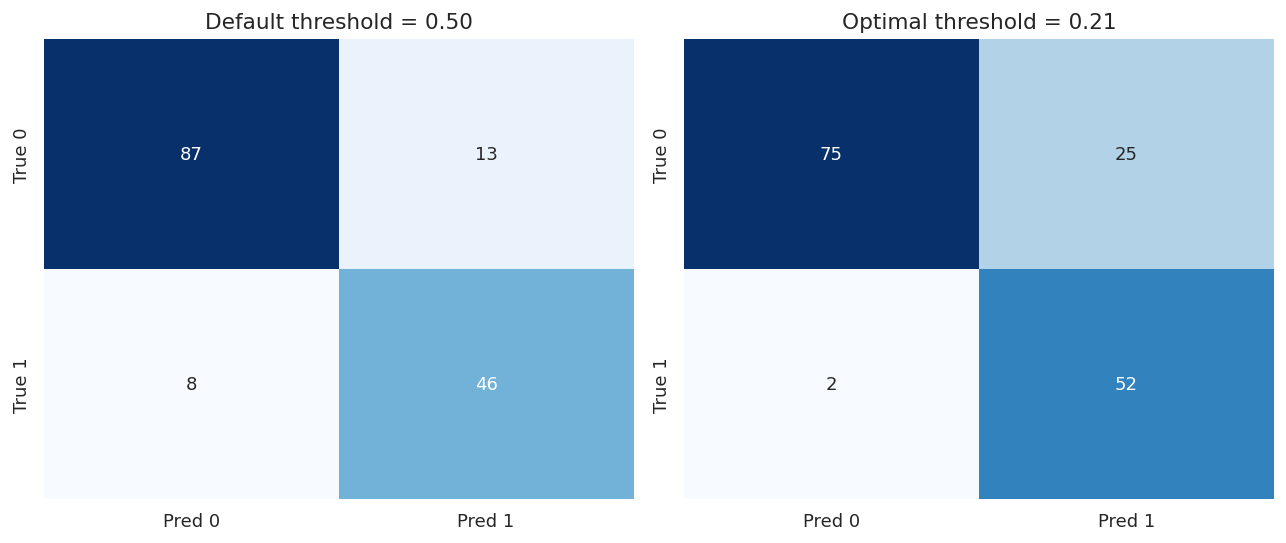

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.3))
for ax, thresh, title in [
    (axes[0], 0.5, "Default threshold = 0.50"),
    (axes[1], best_threshold, f"Optimal threshold = {best_threshold:.2f}"),
]:
    pred = (best_proba >= thresh).astype(int)
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax, cbar=False,
                xticklabels=["Pred 0", "Pred 1"], yticklabels=["True 0", "True 1"])
    ax.set_title(title)
plt.tight_layout()
plt.savefig("outputs/07_confusion_matrices.png", dpi=130)
plt.show()

In [30]:
summary = {
    "best_model": best_overall["model"],
    "best_strategy": best_overall["strategy"],
    "roc_auc": float(best_overall["roc_auc"]),
    "pr_auc": float(best_overall["pr_auc"]),
    "f1_at_0.5": float(best_overall["f1"]),
    "default_cost": float(cost_at_default),
    "optimal_threshold": float(best_threshold),
    "optimal_cost": float(cost_at_best),
    "savings": float(cost_at_default - cost_at_best),
    "savings_pct": float((cost_at_default - cost_at_best) / cost_at_default * 100),
}
print(summary)
pd.Series(summary).to_json("outputs/summary.json")
print("\nAll figures and tables saved to outputs/")


{'best_model': 'Random Forest', 'best_strategy': 'SMOTE-resampled', 'roc_auc': 0.9418518518518518, 'pr_auc': 0.9064482840633066, 'f1_at_0.5': 0.8141592920353983, 'default_cost': 1860.0, 'optimal_threshold': 0.21000000000000002, 'optimal_cost': 900.0, 'savings': 960.0, 'savings_pct': 51.61290322580645}

All figures and tables saved to outputs/
